In [1]:
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([transforms.ToTensor(), 
                                #transforms.Normalize((0.1307,), (0.3081,)),
                                ]) #flatten serve per convertire le immagini in vettori di 784 unità 

mnist_train = MNIST(root='mnist',train=True, download=True, transform=transform)
mnist_test = MNIST(root='mnist',train=False, download=True, transform=transform)


mnist_train_loader = DataLoader(mnist_train, batch_size=1024, num_workers=2, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=1024, num_workers=2)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

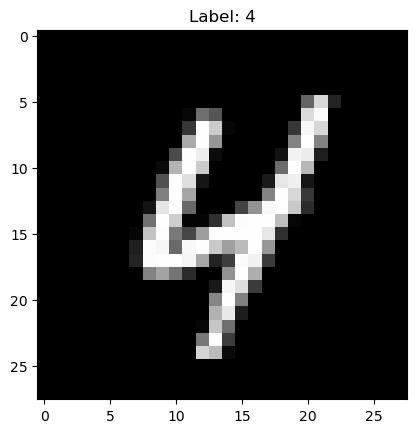

In [3]:
# show a random image from the test set
#random index
idx = np.random.randint(0, len(mnist_test))
image, label = mnist_test[idx]
image = image.squeeze().numpy()
plt.imshow(image, cmap='gray')
plt.title(f'Label: {label}')
plt.show()

Mist data sample is H = 28 and W = 28 pixels.




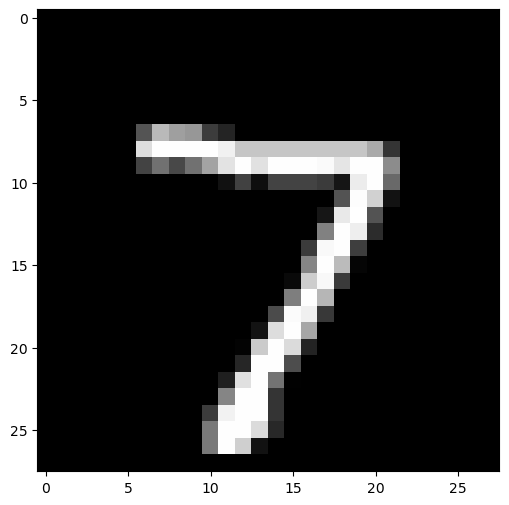

In [4]:
H = 28
W = 28
print('Mist data sample is H =', H, 'and W =', W, 'pixels.')
print('\n')

fig = plt.figure(figsize=(10,6))
#idx = np.random.randint(0, len(mnist_test))
idx = 0
image, label = mnist_test[idx]
image = image.squeeze().numpy()
plt.imshow(image, cmap='gray')

There will be 49 patches, each 4 by 4.




Text(9.5, 1.5, '3')

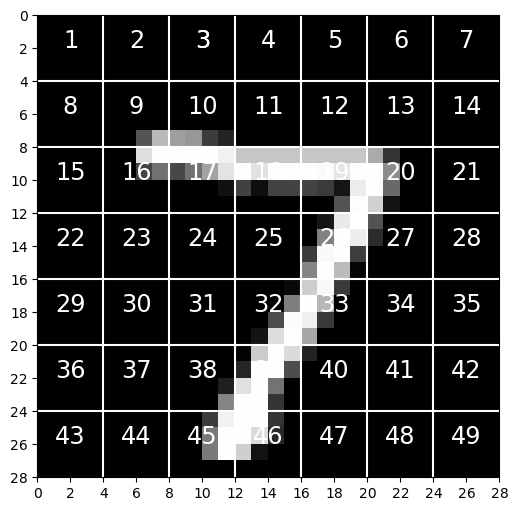

In [5]:
P = 4

N = int((H*W)/(P**2))
print('There will be', N, 'patches, each', P, 'by', str(P)+'.')
print('\n')

fig = plt.figure(figsize=(10,6))
idx = 0
image, label = mnist_test[idx]
image = image.squeeze().numpy()
plt.imshow(image, cmap='gray')
plt.hlines(np.arange(P, H, P)-0.5, -0.5, W-0.5, color='w')
plt.vlines(np.arange(P, W, P)-0.5, -0.5, H-0.5, color='w')
plt.xticks(np.arange(-0.5, W+1, 2), labels=np.arange(0, W+1, 2))
plt.yticks(np.arange(-0.5, H+1, 2), labels=np.arange(0, H+1, 2))
x_text = np.tile(np.arange(1.5, W, P), 7)
y_text = np.repeat(np.arange(1.5, H, P), 7)
for i in range(1, N+1):
    plt.text(x_text[i-1], y_text[i-1], str(i), color='w', fontsize='xx-large', ha='center')
plt.text(x_text[2], y_text[2], str(3), color='w', fontsize='xx-large', ha='center')
#plt.savefig(os.path.join(figure_path, 'mountain_patches.png'), bbox_inches='tight'

Each patch will make a token of length 16.




([], [])

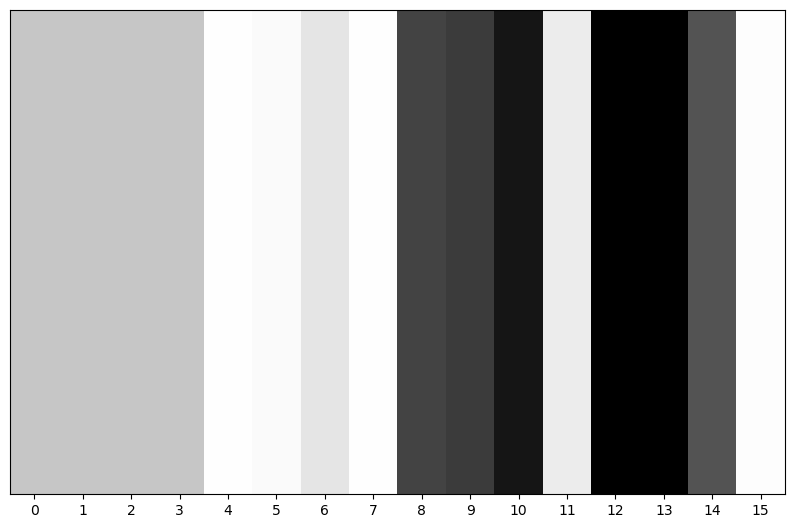

In [6]:
print('Each patch will make a token of length', str(P**2)+'.')
print('\n')

patch19 = image[8:12, 16:20]
token19 = patch19.reshape(1, P**2)

fig = plt.figure(figsize=(10,10))
plt.imshow(token19, aspect=10, cmap='grey')
plt.clim([0,1])
plt.xticks(np.arange(0, 16, 1), labels=np.arange(0, 16, 1))
plt.yticks([])

In [7]:
class Patch_Tokenization(nn.Module):
    def __init__(self,
                img_size: tuple[int, int, int]=(1, 1, 28, 28), #batch_size, channels, height, width
                patch_size: int=4,
                token_len: int=786):

        """ Patch Tokenization Module
            Args:
                img_size (tuple[int, int, int]): size of input (channels, height, width)
                patch_size (int): the side length of a square patch
                token_len (int): desired length of an output token
        """
        super().__init__()

        ## Defining Parameters
        self.img_size = img_size
        C, H, W = self.img_size
        self.patch_size = patch_size
        self.token_len = token_len
        assert H % self.patch_size == 0, 'Height of image must be evenly divisible by patch size.'
        assert W % self.patch_size == 0, 'Width of image must be evenly divisible by patch size.'
        self.num_tokens = (H / self.patch_size) * (W / self.patch_size)

        ## Defining Layers
        self.split = nn.Unfold(kernel_size=self.patch_size, stride=self.patch_size, padding=0)
        self.project = nn.Linear((self.patch_size**2)*C, token_len)

    def forward(self, x):
        x = self.split(x).transpose(1,0)
        x = self.project(x)
        return x

In [8]:
x = torch.from_numpy(image).unsqueeze(0).unsqueeze(0).to(torch.float32)
token_len = 16
print('Input dimensions are\n\tbatchsize:', x.shape[0], '\n\tnumber of input channels:', x.shape[1], '\n\timage size:', (x.shape[2], x.shape[3]))

# Define the Module
patch_tokens = Patch_Tokenization(img_size=(x.shape[1], x.shape[2], x.shape[3]),
                                    patch_size = P,
                                    token_len = token_len)

Input dimensions are
	batchsize: 1 
	number of input channels: 1 
	image size: (28, 28)


In [9]:
x = patch_tokens.split(x).transpose(2,1)
print('After patch tokenization, dimensions are\n\tbatchsize:', x.shape[0], '\n\tnumber of tokens:', x.shape[1], '\n\ttoken length:', x.shape[2])

After patch tokenization, dimensions are
	batchsize: 1 
	number of tokens: 49 
	token length: 16


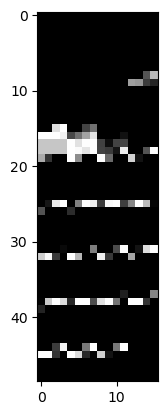

In [10]:
tokens_plot = x.squeeze().numpy()
plt.imshow(tokens_plot, cmap='gray')

In [11]:
x = patch_tokens.project(x)
print('After projection, dimensions are\n\tbatchsize:', x.shape[0], '\n\tnumber of tokens:', x.shape[1], '\n\ttoken length:', x.shape[2])

After projection, dimensions are
	batchsize: 1 
	number of tokens: 49 
	token length: 16
